<a href="https://colab.research.google.com/github/ashwanigpt13/Employee_Attrition/blob/main/Employee_attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
import numpy as np

In [41]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [43]:
df = pd.read_csv('/content/Employee_HR.csv')

In [44]:
df.head()

,EmpId,Satisfaction,Evaluation,number_of_projects,average_montly_hours,time_spent_company,work_accident,Promotion,Department,Salary_INR,Churn
0,780152,3.8,5.3,2,157,3,0,0,sales,11053,1
1,780153,8.0,8.6,5,262,6,0,0,sales,54063,1
2,780154,1.1,8.8,7,272,4,0,0,sales,61300,1
3,780155,7.2,8.7,5,223,5,0,0,sales,20647,1
4,780156,3.7,5.2,2,159,3,0,0,sales,17808,1


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   EmpId                 14999 non-null  int64  
 1   Satisfaction          14999 non-null  float64
 2   Evaluation            14999 non-null  float64
 3   number_of_projects    14999 non-null  int64  
 4   average_montly_hours  14999 non-null  int64  
 5   time_spent_company    14999 non-null  int64  
 6   work_accident         14999 non-null  int64  
 7   Promotion             14999 non-null  int64  
 8   Department            14999 non-null  object 
 9   Salary_INR            14999 non-null  int64  
 10  Churn                 14999 non-null  int64  
dtypes: float64(2), int64(8), object(1)
memory usage: 1.3+ MB


In [46]:
df.describe()

,EmpId,Satisfaction,Evaluation,number_of_projects,average_montly_hours,time_spent_company,work_accident,Promotion,Salary_INR,Churn
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,787651.000000,6.128335,7.161017,3.803054,201.050337,3.498233,0.144610,0.021268,62742.699913,0.238083
std,4329.982679,2.486307,1.711691,1.232592,49.943099,1.460136,0.351719,0.144281,66486.116149,0.425924
min,780152.000000,0.900000,3.600000,2.000000,96.000000,2.000000,0.000000,0.000000,10000.000000,0.000000
25%,783901.500000,4.400000,5.600000,3.000000,156.000000,3.000000,0.000000,0.000000,25248.000000,0.000000
50%,787651.000000,6.400000,7.200000,4.000000,200.000000,3.000000,0.000000,0.000000,41721.000000,0.000000
75%,791400.500000,8.200000,8.700000,5.000000,245.000000,4.000000,0.000000,0.000000,76354.000000,0.000000
max,795150.000000,10.000000,10.000000,7.000000,310.000000,10.000000,1.000000,1.000000,399930.000000,1.000000


In [47]:
df.isnull().sum()

,0
EmpId,0
Satisfaction,0
Evaluation,0
number_of_projects,0
average_montly_hours,0
time_spent_company,0
work_accident,0
Promotion,0
Department,0
Salary_INR,0


In [48]:
df.shape


(14999, 11)

In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
df["Churn"].value_counts()

,count
Churn,
0,11428
1,3571


In [51]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
0,76.191746
1,23.808254


In [52]:
df["Department"].value_counts()

,count
Department,
sales,4140
technical,2720
support,2229
IT,1227
product_mng,902
marketing,858
RandD,787
accounting,767
hr,739


In [55]:
df = df.drop("EmpId", axis=1)

KeyError: "['EmpId'] not found in axis"

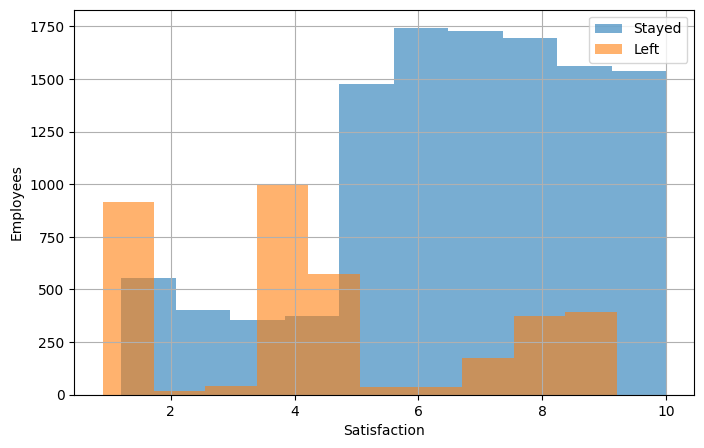

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df[df["Churn"]==0]["Satisfaction"].hist(alpha=0.6,label="Stayed")
df[df["Churn"]==1]["Satisfaction"].hist(alpha=0.6,label="Left")

plt.xlabel("Satisfaction")
plt.ylabel("Employees")
plt.legend()
plt.show()

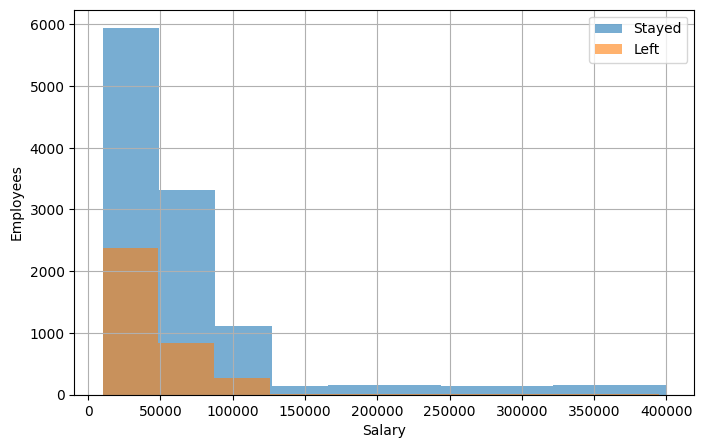

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df[df["Churn"]==0]["Salary_INR"].hist(alpha=0.6,label="Stayed")
df[df["Churn"]==1]["Salary_INR"].hist(alpha=0.6,label="Left")

plt.xlabel("Salary")
plt.ylabel("Employees")
plt.legend()
plt.show()

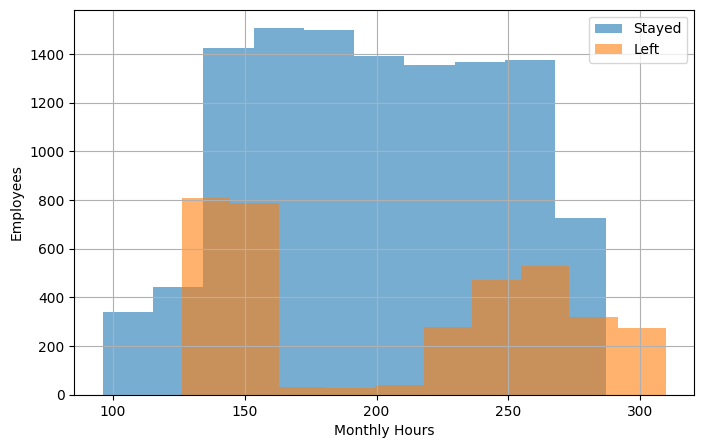

In [58]:
plt.figure(figsize=(8,5))

df[df["Churn"]==0]["average_montly_hours"].hist(alpha=0.6,label="Stayed")
df[df["Churn"]==1]["average_montly_hours"].hist(alpha=0.6,label="Left")

plt.xlabel("Monthly Hours")
plt.ylabel("Employees")
plt.legend()
plt.show()

In [59]:
import pandas as pd

department_churn = pd.crosstab(df["Department"], df["Churn"])

department_churn

Churn,0,1
Department,,
IT,954,273
RandD,666,121
accounting,563,204
hr,524,215
management,539,91
marketing,655,203
product_mng,704,198
sales,3126,1014
support,1674,555


In [60]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


In [62]:

categorical_features = ["Department"]
numerical_features = [col for col in X.columns if col != "Department"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [65]:
from sklearn.pipeline import Pipeline


In [66]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Department']),
                                                 ('num', 'passthrough',
                                                  ['Satisfaction', 'Evaluation',
                                                   'number_of_projects',
                                                   'average_montly_hours',
                                                   'time_spent_company',
                                                   'work_accident', 'Promotion',
                                                   'Salary_INR'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [68]:
y_pred = model.predict(X_test)

In [69]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9863333333333333

Classification Report

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2294
           1       0.99      0.95      0.97       706

    accuracy                           0.99      3000
   macro avg       0.99      0.97      0.98      3000
weighted avg       0.99      0.99      0.99      3000


Confusion Matrix

[[2287    7]
 [  34  672]]


In [70]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importances = model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
10,num__Satisfaction,0.326726
14,num__time_spent_company,0.181491
12,num__number_of_projects,0.173541
13,num__average_montly_hours,0.145946
11,num__Evaluation,0.111759
17,num__Salary_INR,0.032775
15,num__work_accident,0.009092
9,cat__Department_technical,0.003040
7,cat__Department_sales,0.002875
8,cat__Department_support,0.002280


In [71]:
new_employee = pd.DataFrame({
    "Satisfaction":[4.5],
    "Evaluation":[7.5],
    "number_of_projects":[4],
    "average_montly_hours":[180],
    "time_spent_company":[3],
    "work_accident":[0],
    "Promotion":[0],
    "Department":["IT"],
    "Salary_INR":[60000]
})

prediction = model.predict(new_employee)

probability = model.predict_proba(new_employee)

print("Prediction :", prediction[0])

print("Probability :", probability)

Prediction : 0
Probability : [[0.99 0.01]]


In [72]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importance = model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
10,num__Satisfaction,0.326726
14,num__time_spent_company,0.181491
12,num__number_of_projects,0.173541
13,num__average_montly_hours,0.145946
11,num__Evaluation,0.111759
17,num__Salary_INR,0.032775
15,num__work_accident,0.009092
9,cat__Department_technical,0.003040
7,cat__Department_sales,0.002875
8,cat__Department_support,0.002280


In [73]:
import joblib

In [74]:
joblib.dump(model, "employee_attrition_model.pkl")

['employee_attrition_model.pkl']